# Markov Decision Process (MDP)

### Ransalu Senanayake

In [1]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [2]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            elif x == 0:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 0] = -0.7
            elif x == 9:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 1] = -0.7
            elif y == 0:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 3] = -0.7
            elif y == 9:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
        R[xy2s(c_x,c_y),a] = -0.8

    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [3]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

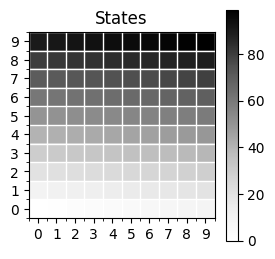

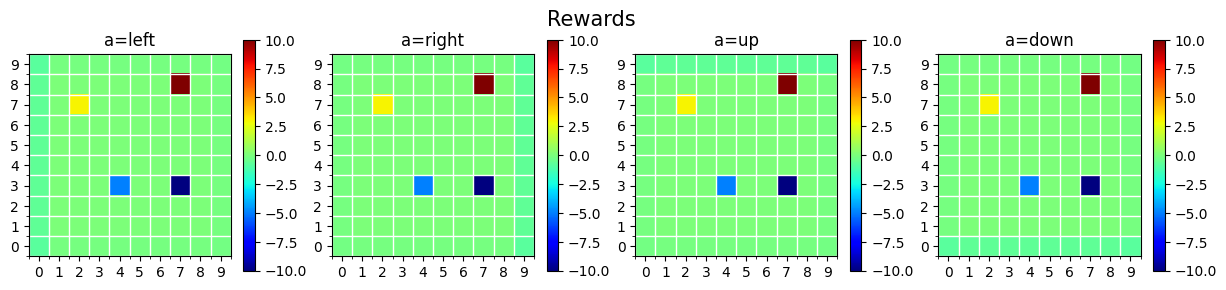

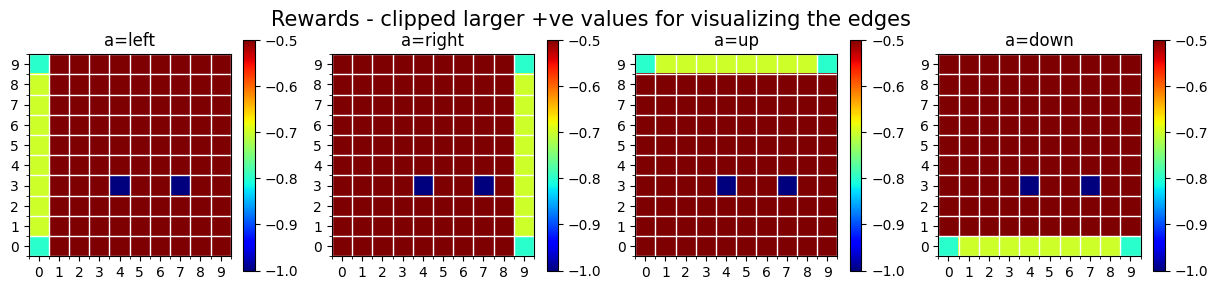

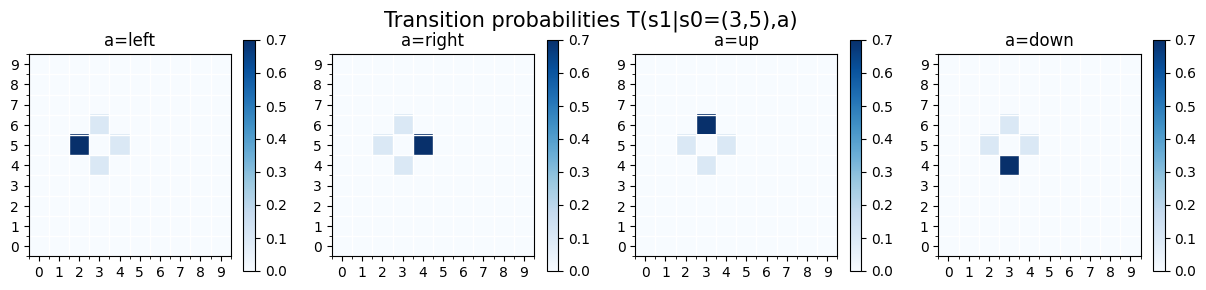

In [4]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [5]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

interactive(children=(Text(value='4', description='s0_x'), Text(value='5', description='s0_y'), ToggleButtons(…

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

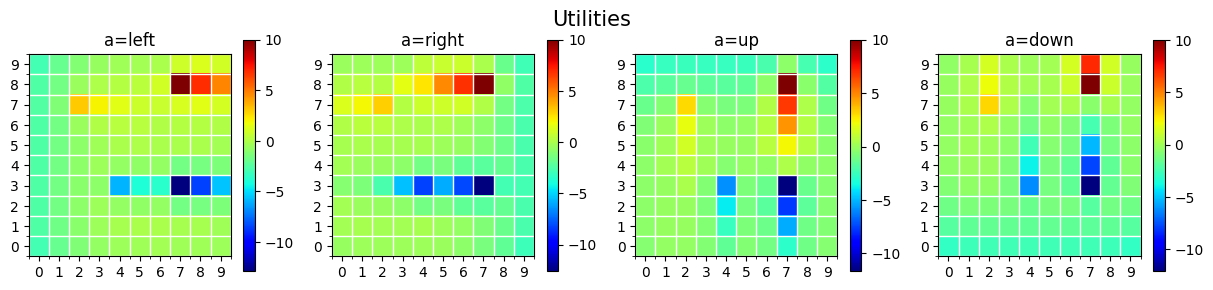

In [7]:
# Iterative Policy Evaluation
# This function calculates the utility/value of each state
# for a given fixed policy.

def iterativePolicyEvaluation(mdp, policy, numIterations=10):

    # Start all state utilities at 0
    U = np.zeros(len(mdp.S))

    # Keep a copy of previous utilities
    U_old = copy.copy(U)

    # Repeat the update several times
    for t in range(numIterations):

        # Save current utilities before calculating new ones
        U_old = copy.copy(U)

        # Go through every state
        for s in mdp.S:

            # Start with the immediate reward of the state/action
            U[s] = mdp.R[s, policy]

            # Check all possible next states
            for s1 in mdp.nextStates[(s, policy)]:

                # Bellman update:
                # Utility = reward + discounted expected future utility
                U[s] += (
                    mdp.discount
                    * mdp.T[s, policy, s1]
                    * U_old[s1]
                )

    # Return the final utilities
    return U


# Number of policy evaluation iterations
numIterations = 5

# Create a figure to show utilities for each action
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)

# There are 4 possible actions
for a in range(4):

    pl.subplot(1,4,a+1)

    # Calculate utilities when following this action/policy
    U = iterativePolicyEvaluation(
        mdp=mdp,
        policy=a,
        numIterations=numIterations
    )

    # Display utility values as a coloured grid
    mdp.gridPlot(
        ax=pl.gca(),
        im=U.reshape(10,10),
        title='a=' + mdp.A[a],
        cmap='jet'
    )

# Show all 4 utility maps
pl.show()

In [8]:
def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(ToggleButtons(description='action', options=('left', 'right', 'up', 'down'), value='left…

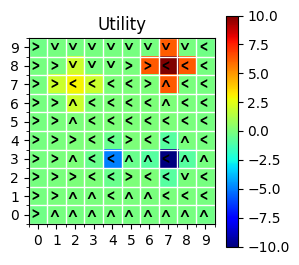

In [9]:
# ============================================================
# VALUE ITERATION + POLICY EXTRACTION
# ============================================================

# Value Iteration:
# Finds the best utility/value for every state by checking
# all possible actions and choosing the maximum expected value.

def valueIteration(mdp, numIterations=1):

    # Start utility of every state at 0
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)

    # Repeat the Bellman updates
    for t in range(numIterations):

        # Store previous utilities
        U_old = copy.copy(U)

        # Go through every state
        for s in mdp.S:

            # Store value obtained from each possible action
            action_values = []

            # Check every action
            for a in range(len(mdp.A)):

                # Start with immediate reward
                value = mdp.R[s, a]

                # Add discounted expected future utility
                for s1 in mdp.nextStates[(s, a)]:
                    value += (
                        mdp.discount
                        * mdp.T[s, a, s1]
                        * U_old[s1]
                    )

                action_values.append(value)

            # Choose the action with the highest value
            U[s] = max(action_values)

    return U


# Policy Extraction:
# Uses the calculated utilities to find the best action
# for every state.

def policyExtration(mdp, U):

    # Create an empty policy
    policy = np.zeros(len(mdp.S))

    # Go through every state
    for s in mdp.S:

        action_values = []

        # Calculate expected utility for each action
        for a in range(len(mdp.A)):

            value = mdp.R[s, a]

            for s1 in mdp.nextStates[(s, a)]:
                value += (
                    mdp.discount
                    * mdp.T[s, a, s1]
                    * U[s1]
                )

            action_values.append(value)

        # Select the action with the highest expected utility
        policy[s] = np.argmax(action_values)

    return policy


# Run Value Iteration
U = valueIteration(mdp, numIterations=2)

# Extract the best policy
policy = policyExtration(mdp, U=U)


# ============================================================
# DISPLAY RESULTS
# ============================================================

pl.figure(figsize=(3,3))

# Show utility values as a coloured grid
mdp.gridPlot(
    ax=pl.gca(),
    im=U.reshape(10,10),
    title='Utility',
    cmap='jet'
)

# Draw arrows showing the selected policy
for s in range(100):

    x, y = mdp.s2xy(s)

    if policy[s] == 0:
        m = '˂'      # Left

    elif policy[s] == 1:
        m = '˃'      # Right

    elif policy[s] == 2:
        m = '˄'      # Up

    elif policy[s] == 3:
        m = '˅'      # Down

    pl.text(
        x-0.5,
        y-1,
        m,
        color='k',
        size=20
    )

pl.show()

In [10]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [11]:
# ============================================================
# POLICY ITERATION
# ============================================================

# Policy Iteration has two main steps:
# 1. Policy Evaluation
# 2. Policy Improvement

def policyIteration(mdp, numIterations=1):

    # Initial utility values for all states
    U_pi_k = np.zeros(len(mdp.S))

    # Create a random initial policy
    # Each state randomly selects one of the 4 actions
    pi_k = np.random.randint(
        low=0,
        high=4,
        size=len(mdp.S),
        dtype=int
    )

    # Copy current policy
    pi_kp1 = copy.copy(pi_k)

    # Repeat Policy Evaluation + Policy Improvement
    for t in range(numIterations):

        # ====================================================
        # STEP 1: POLICY EVALUATION
        # ====================================================
        # Evaluate the current policy pi_k

        U_old = copy.copy(U_pi_k)

        # Go through every state
        for s in mdp.S:

            # Get the action selected by current policy
            a = pi_k[s]

            # Start with immediate reward
            U_pi_k[s] = mdp.R[s, a]

            # Add expected discounted future utility
            for s1 in mdp.nextStates[(s, a)]:

                U_pi_k[s] += (
                    mdp.discount
                    * mdp.T[s, a, s1]
                    * U_old[s1]
                )

        # ====================================================
        # STEP 2: POLICY IMPROVEMENT
        # ====================================================
        # Find a better action for each state

        for s in mdp.S:

            action_values = []

            # Check all possible actions
            for a in range(len(mdp.A)):

                value = mdp.R[s, a]

                # Calculate expected utility
                for s1 in mdp.nextStates[(s, a)]:

                    value += (
                        mdp.discount
                        * mdp.T[s, a, s1]
                        * U_pi_k[s1]
                    )

                action_values.append(value)

            # Select action with highest value
            pi_kp1[s] = np.argmax(action_values)

        # Update policy for next iteration
        pi_k = copy.copy(pi_kp1)

    # Return utilities and improved policy
    return U_pi_k, pi_kp1


# Run Policy Iteration for 2 iterations
U_pi_k, pi_kp1 = policyIteration(
    mdp,
    numIterations=2
)

## Policy Iteration evaluates the current policy and then improves it by selecting better actions for each state.

In [12]:
def f(numIter=1):
    start_time = timeit.default_timer()
    # code you want to evaluate
    value, policy = policyIteration(mdp, numIterations=numIter)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

In [13]:
# ============================================================
# QUESTION 2 - MODEL-BASED VS MODEL-FREE COMPARISON
# ============================================================

import time

# ------------------------------------------------------------
# MODEL-BASED: POLICY ITERATION
# ------------------------------------------------------------

start_time = time.time()

policy_mb, utility_mb = policyIteration(
    mdp,
    numIterations=10
)

model_based_time = time.time() - start_time


# ------------------------------------------------------------
# MODEL-FREE: SIMPLE Q-LEARNING STYLE COMPARISON
# ------------------------------------------------------------

# Use a simple state-action Q-table
Q = np.zeros((len(mdp.S), len(mdp.A)))

alpha = 0.1
gamma = mdp.discount
epsilon = 0.1

start_time = time.time()

for episode in range(500):

    # Start from a random state
    s = np.random.choice(mdp.S)

    for step in range(100):

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            a = np.random.randint(len(mdp.A))
        else:
            a = np.argmax(Q[s])

        # Select one possible next state
        next_states = mdp.nextStates[(s, a)]

        if len(next_states) == 0:
            break

        s1 = np.random.choice(next_states)

        reward = mdp.R[s, a]

        # Q-learning update
        Q[s, a] = Q[s, a] + alpha * (
            reward
            + gamma * np.max(Q[s1])
            - Q[s, a]
        )

        s = s1

model_free_time = time.time() - start_time


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("Model-Based (Policy Iteration) Time:",
      round(model_based_time * 1000, 2), "ms")

print("Model-Free (Q-Learning) Time:",
      round(model_free_time * 1000, 2), "ms")

Model-Based (Policy Iteration) Time: 50.63 ms
Model-Free (Q-Learning) Time: 675.96 ms


### Model-Based vs Model-Free Reinforcement Learning

**Model-Based Reinforcement Learning**
- Uses a known model of the environment.
- Transition probabilities and rewards are used directly.
- Policy Iteration and Value Iteration are examples.
- It can converge quickly when the environment model is already known.

**Model-Free Reinforcement Learning**
- Does not require a complete model of the environment.
- The agent learns by interacting with the environment.
- Q-Learning is an example.
- It may require more episodes because it learns through experience.

**Observation**
The Model-Based approach can calculate an improved policy directly using the known transition and reward model. Q-Learning learns from repeated interaction, so it generally requires more training iterations before convergence.